<h1 style="font-family:verdana;"><center>Phân Khúc Khách Hàng Online Retail II</center></h1>

<h3 style="font-family:verdana;"><center>sử dụng K-Means, DBSCAN và Agglomerative Clustering</center></h3>

>Tập dữ liệu **Online Retail II** chứa các giao dịch mua hàng thực tế của một cửa hàng bán lẻ trực tuyến tại Anh trong giai đoạn 01/12/2009 – 09/12/2011. Mỗi dòng là một mặt hàng trong hóa đơn.

> **Mục tiêu:** Xây dựng đặc trưng **RFM (Recency – Frequency – Monetary)** từ dữ liệu giao dịch thô, sau đó áp dụng ba thuật toán phân cụm để phân khúc khách hàng một cách hiệu quả.

# 1. Nhập Thư Viện

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", lambda x: "%.2f" % x)
print("Thư viện đã sẵn sàng!")

Thư viện đã sẵn sàng!


# 2. Tải & Khám Phá Dữ Liệu Thô

File Excel có 2 sheet tương ứng với 2 năm. Ta gộp cả hai lại.

In [33]:
PATH = r"C:\Users\khact\Desktop\ML\BTL\papers\method\Customer_Classification\online_retail_II.xlsx"

df1 = pd.read_excel(PATH, sheet_name="Year 2009-2010")
df2 = pd.read_excel(PATH, sheet_name="Year 2010-2011")
df = pd.concat([df1, df2], ignore_index=True)

print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [34]:
print("Thông tin tổng quan:")
df.info()
print("\nThống kê mô tả:")
df.describe()

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB

Thống kê mô tả:


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


In [35]:
print("Giá trị null theo cột:")
print(df.isnull().sum())
print(f"\nTỷ lệ null Customer ID: {df['Customer ID'].isnull().mean()*100:.1f}%")

Giá trị null theo cột:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Tỷ lệ null Customer ID: 22.8%


# 3. Tiền Xử Lý Dữ Liệu

Các bước làm sạch:
1. Loại bỏ dòng không có `Customer ID`
2. Loại bỏ hóa đơn bị hủy (Invoice bắt đầu bằng chữ "C")
3. Loại bỏ `Quantity <= 0` và `Price <= 0`
4. Loại bỏ mã hàng không hợp lệ (StockCode thuần số hoặc mã đặc biệt)

In [36]:
df_clean = df.copy()

# 1. Bỏ dòng không có Customer ID
df_clean = df_clean.dropna(subset=["Customer ID"])
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)

# 2. Bỏ hóa đơn hủy
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]

# 3. Bỏ số lượng và giá không hợp lệ
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]

# 4. Tính doanh thu từng dòng
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

print("Sau khi làm sạch:", df_clean.shape)
print(f"Số khách hàng: {df_clean['Customer ID'].nunique()}")
print(f"Khoảng thời gian: {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")
df_clean.head()

Sau khi làm sạch: (805549, 9)
Số khách hàng: 5878
Khoảng thời gian: 2009-12-01 → 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


## 3.1 Xây Dựng Đặc Trưng RFM

| Đặc trưng | Ý nghĩa |
|-----------|----------|
| **Recency (R)** | Số ngày kể từ lần mua cuối cùng — càng nhỏ càng tốt |
| **Frequency (F)** | Số hóa đơn khác nhau — càng nhiều càng tốt |
| **Monetary (M)** | Tổng doanh thu — càng lớn càng tốt |

In [37]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Invoice",     "nunique"),
    Monetary  = ("Revenue",     "sum")
).reset_index()

print("RFM shape:", rfm.shape)
print("\nThống kê RFM:")
rfm.describe()

RFM shape: (5878, 4)

Thống kê RFM:


,Customer ID,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,3018.62
std,1715.57,209.34,13.01,14737.73
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,348.76
50%,15314.50,96.00,3.00,898.91
75%,16797.75,380.00,7.00,2307.09
max,18287.00,739.00,398.00,608821.65


# 4. Trực Quan Hóa Dữ Liệu (EDA)

## 4.1 Phân phối RFM

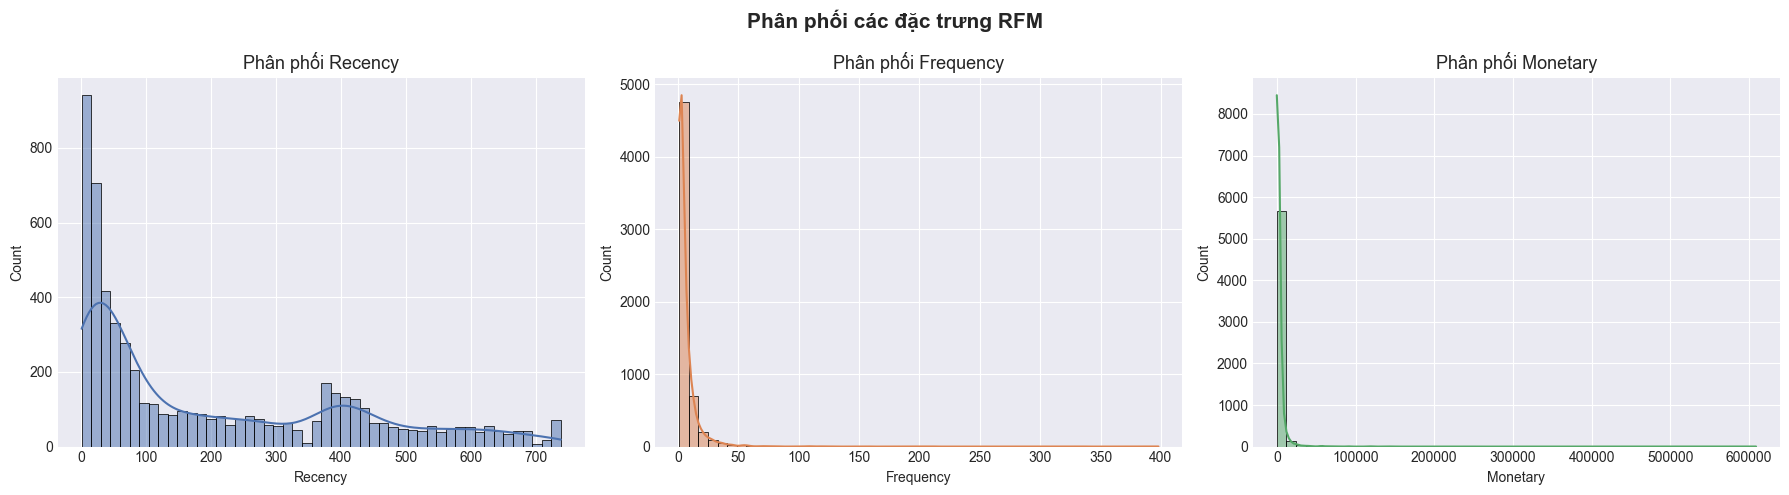

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#4C72B0", "#DD8452", "#55A868"]):
    sns.histplot(rfm[col], bins=50, ax=ax, color=color, kde=True)
    ax.set_title(f"Phân phối {col}", fontsize=13)
    ax.set_xlabel(col)

plt.suptitle("Phân phối các đặc trưng RFM", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.2 Boxplot phát hiện ngoại lệ

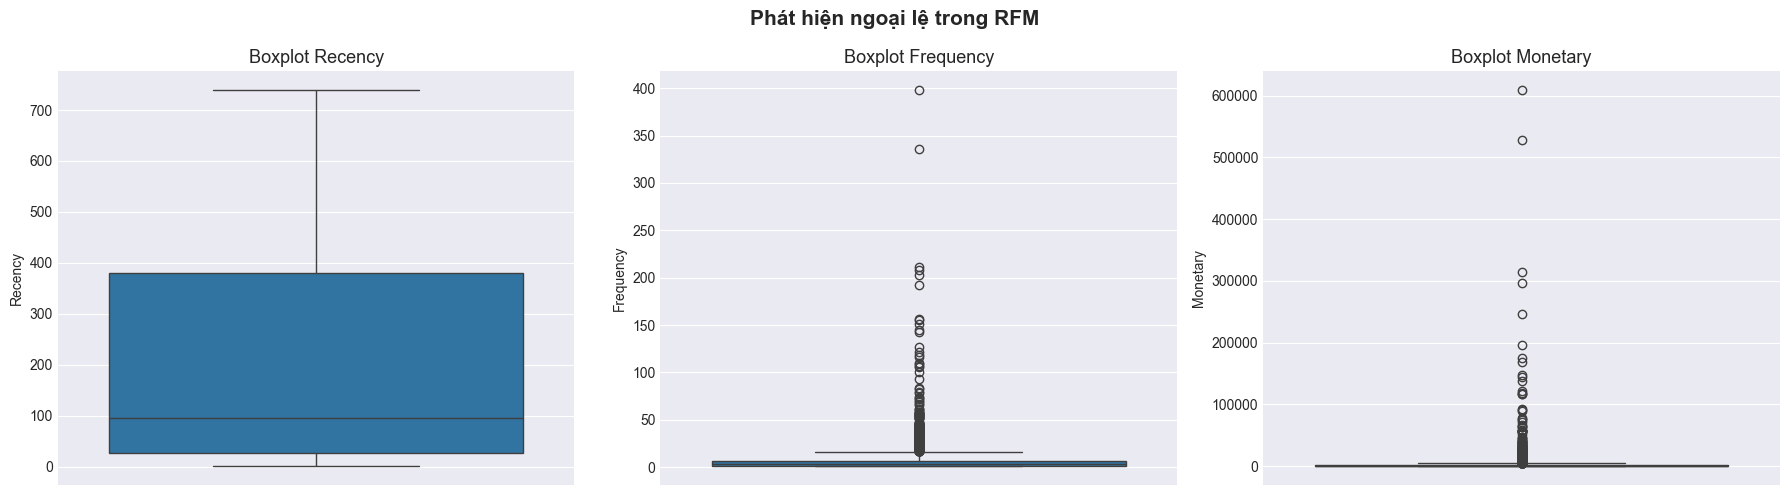

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(y=rfm[col], ax=ax)
    ax.set_title(f"Boxplot {col}", fontsize=13)

plt.suptitle("Phát hiện ngoại lệ trong RFM", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.3 Scatter plot giữa các cặp RFM

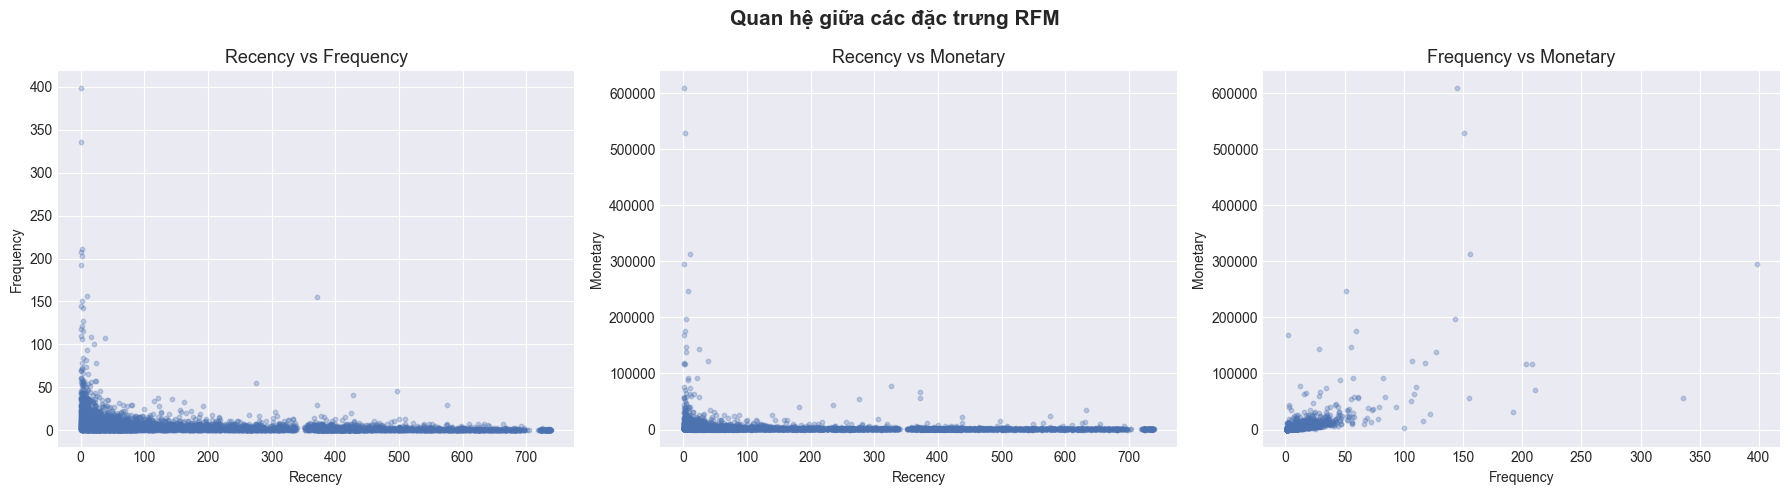

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [("Recency", "Frequency"), ("Recency", "Monetary"), ("Frequency", "Monetary")]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(rfm[x], rfm[y], alpha=0.3, s=10, color="#4C72B0")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}", fontsize=13)

plt.suptitle("Quan hệ giữa các đặc trưng RFM", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.4 Ma trận tương quan

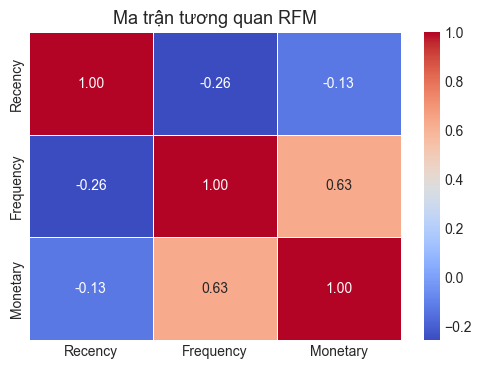

In [41]:
plt.figure(figsize=(6, 4))
sns.heatmap(rfm[["Recency","Frequency","Monetary"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Ma trận tương quan RFM", fontsize=13)
plt.show()

## 4.5 Top 10 quốc gia theo doanh thu

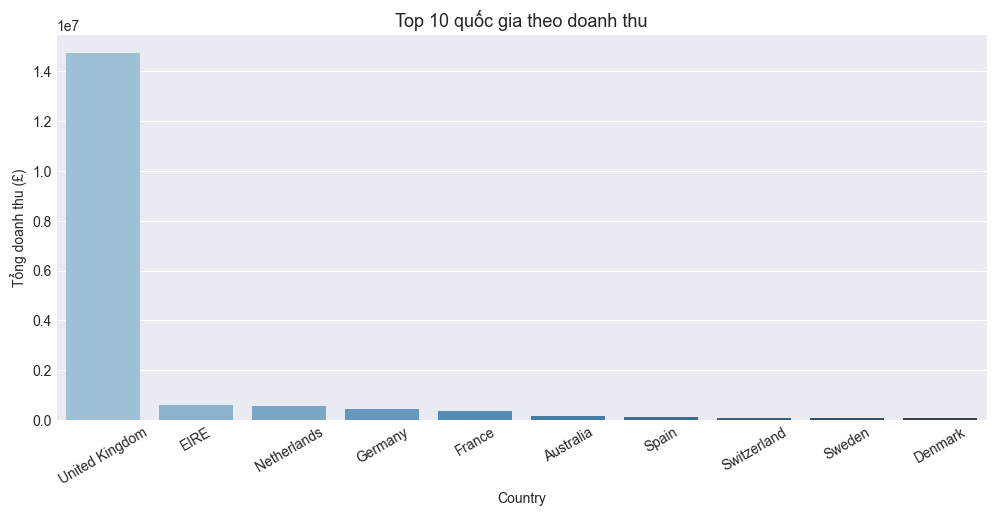

In [42]:
top_countries = df_clean.groupby("Country")["Revenue"].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x="Country", y="Revenue", palette="Blues_d")
plt.title("Top 10 quốc gia theo doanh thu", fontsize=13)
plt.xticks(rotation=30)
plt.ylabel("Tổng doanh thu (£)")
plt.show()

## 4.6 Doanh thu theo tháng

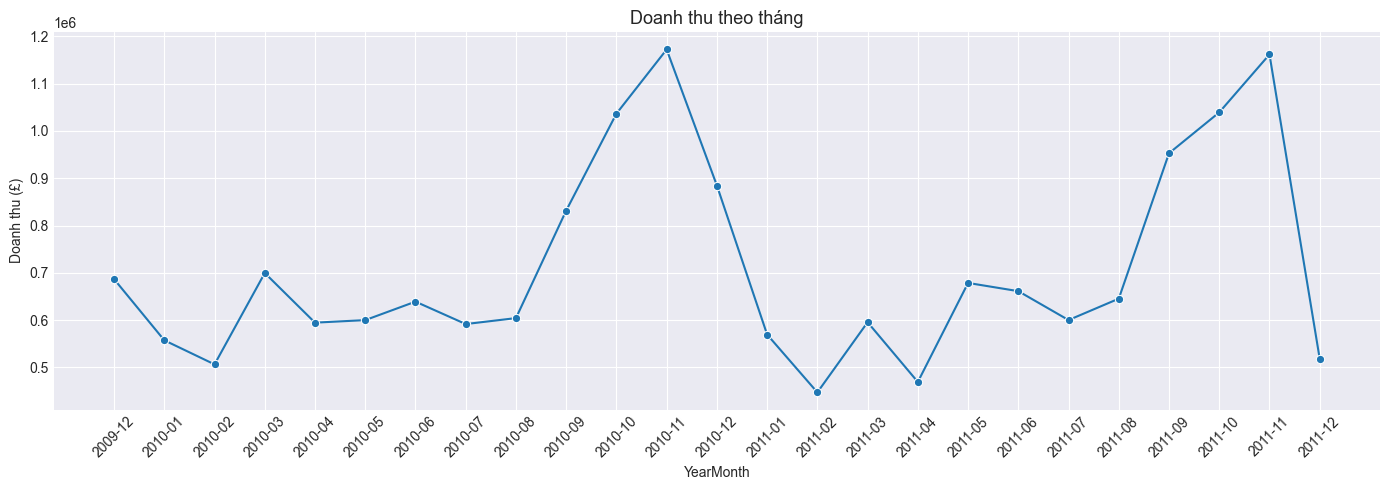

In [43]:
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")
monthly = df_clean.groupby("YearMonth")["Revenue"].sum().reset_index()
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly, x="YearMonth", y="Revenue", marker="o")
plt.title("Doanh thu theo tháng", fontsize=13)
plt.xticks(rotation=45)
plt.ylabel("Doanh thu (£)")
plt.tight_layout()
plt.show()

# 5. Chuẩn Hóa Dữ Liệu

RFM có độ lệch (skew) lớn — đặc biệt Monetary. Ta dùng **log transform** trước, sau đó **StandardScaler**.

Dữ liệu sau chuẩn hóa (5 dòng đầu):
   Recency  Frequency  Monetary
0     0.86       1.25      3.19
1    -2.15       0.80      1.30
2    -0.08       0.30      0.56
3    -0.94       0.07      1.12
4     0.82      -1.06     -0.74


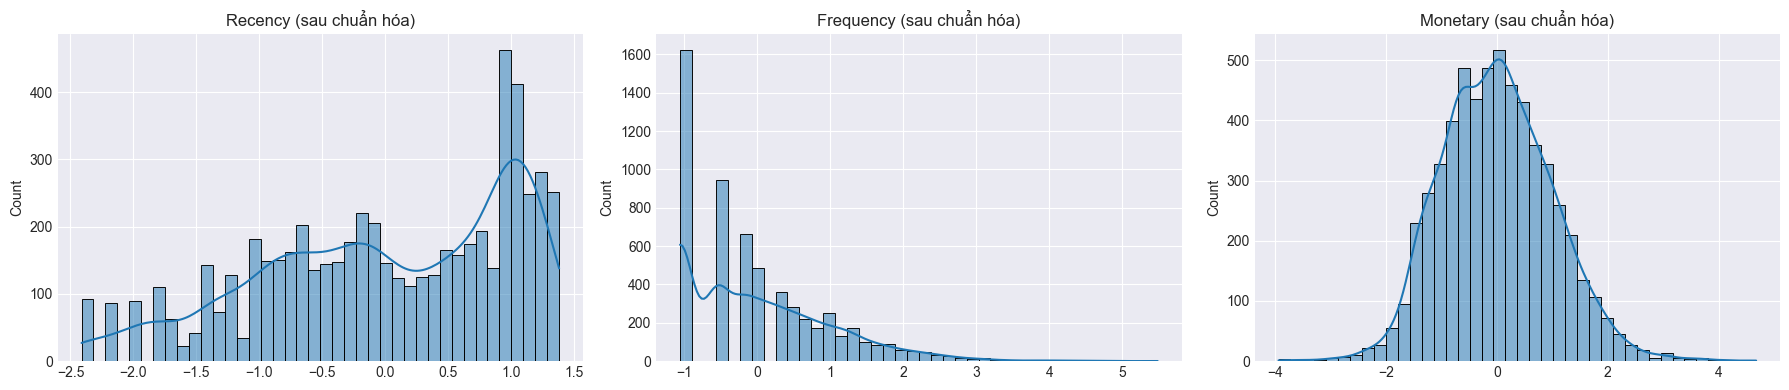

In [44]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_log["Recency"]   = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"]  = np.log1p(rfm_log["Monetary"])

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

print("Dữ liệu sau chuẩn hóa (5 dòng đầu):")
print(pd.DataFrame(X, columns=["Recency","Frequency","Monetary"]).head())

# Kiểm tra phân phối sau log + scale
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, i in zip(axes, ["Recency","Frequency","Monetary"], range(3)):
    sns.histplot(X[:, i], bins=40, ax=ax, kde=True)
    ax.set_title(f"{col} (sau chuẩn hóa)")
plt.tight_layout()
plt.show()

# 6. Các Hàm Đánh Giá Phân Cụm

In [45]:
def plot_elbow_silhouette(X, k_range=range(2, 11)):
    """Vẽ Elbow Method và Silhouette Score để chọn K tối ưu."""
    sse, sil = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
        km.fit(X)
        sse.append(km.inertia_)
        sil.append(silhouette_score(X, km.labels_))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(list(k_range), sse, "bo-")
    ax1.set_title("Elbow Method"); ax1.set_xlabel("Số cụm K"); ax1.set_ylabel("SSE (Inertia)")
    ax2.plot(list(k_range), sil, "ro-")
    ax2.set_title("Silhouette Score"); ax2.set_xlabel("Số cụm K"); ax2.set_ylabel("Silhouette Score")
    plt.suptitle("Lựa chọn số cụm K tối ưu", fontsize=14, fontweight="bold")
    plt.show()
    return sse, sil


def print_scores(labels, X, name):
    """In Silhouette Score và Davies-Bouldin Index."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        print(f"[{name}] Không đủ cụm để đánh giá.")
        return
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    print(f"[{name}] Số cụm: {n_clusters} | Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")


def plot_silhouette(X, labels, title):
    """Vẽ biểu đồ Silhouette chi tiết."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    sil_avg = silhouette_score(X, labels)
    sample_sil = silhouette_samples(X, labels)
    y_lower = 10
    for i in sorted(set(labels)):
        if i == -1: continue
        vals = sample_sil[labels == i]
        vals.sort()
        y_upper = y_lower + len(vals)
        color = cm.tab10(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * len(vals), str(i))
        y_lower = y_upper + 10
    ax1.axvline(x=sil_avg, color="red", linestyle="--")
    ax1.set_title("Biểu đồ Silhouette"); ax1.set_xlabel("Hệ số Silhouette"); ax1.set_ylabel("Nhãn cụm")
    ax1.set_yticks([])
    # PCA 2D để vẽ scatter
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    scatter = ax2.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="tab10", alpha=0.6, s=15)
    ax2.set_title("Trực quan hóa cụm (PCA 2D)"); ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
    plt.colorbar(scatter, ax=ax2)
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.show()


def plot_rfm_clusters(rfm_df, labels, title):
    """Vẽ đặc trưng trung bình RFM theo từng cụm."""
    rfm_plot = rfm_df[["Recency","Frequency","Monetary"]].copy()
    rfm_plot["Cluster"] = labels
    rfm_plot = rfm_plot[rfm_plot["Cluster"] != -1]
    means = rfm_plot.groupby("Cluster").mean()
    means_norm = (means - means.min()) / (means.max() - means.min())
    means_norm.T.plot(kind="bar", figsize=(10, 5), colormap="tab10")
    plt.title(f"Đặc trưng trung bình RFM theo cụm — {title}", fontsize=13)
    plt.ylabel("Giá trị chuẩn hóa (0-1)")
    plt.xticks(rotation=0)
    plt.legend(title="Cụm", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()
    return means


print("Các hàm tiện ích đã được định nghĩa!")

Các hàm tiện ích đã được định nghĩa!


# 7. Phân Cụm K-Means

**K-Means** là thuật toán phân cụm dựa trên tâm cụm (centroid-based). Thuật toán lặp lại hai bước: gán mỗi điểm vào cụm gần nhất, rồi cập nhật lại tâm cụm.

**Bước 1:** Dùng Elbow Method và Silhouette Score để chọn K tối ưu.

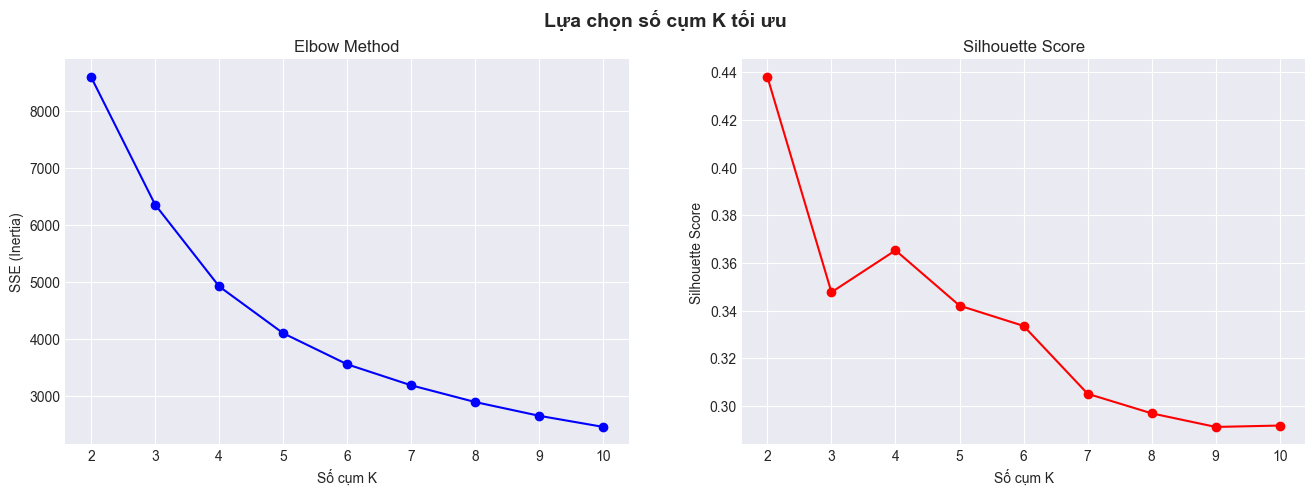

In [46]:
sse, sil = plot_elbow_silhouette(X)

**Bước 2:** Huấn luyện K-Means với K tối ưu và đánh giá.

In [47]:
K_OPTIMAL = 4  # Điều chỉnh dựa trên biểu đồ ở trên

kmeans = KMeans(n_clusters=K_OPTIMAL, init="k-means++", random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)
rfm["KMeans_Cluster"] = km_labels

print_scores(km_labels, X, "K-Means")
print("\nSố khách hàng mỗi cụm:")
print(pd.Series(km_labels).value_counts().sort_index())

[K-Means] Số cụm: 4 | Silhouette: 0.3653 | Davies-Bouldin: 0.9303

Số khách hàng mỗi cụm:
0    1188
1    1974
2    1465
3    1251
Name: count, dtype: int64


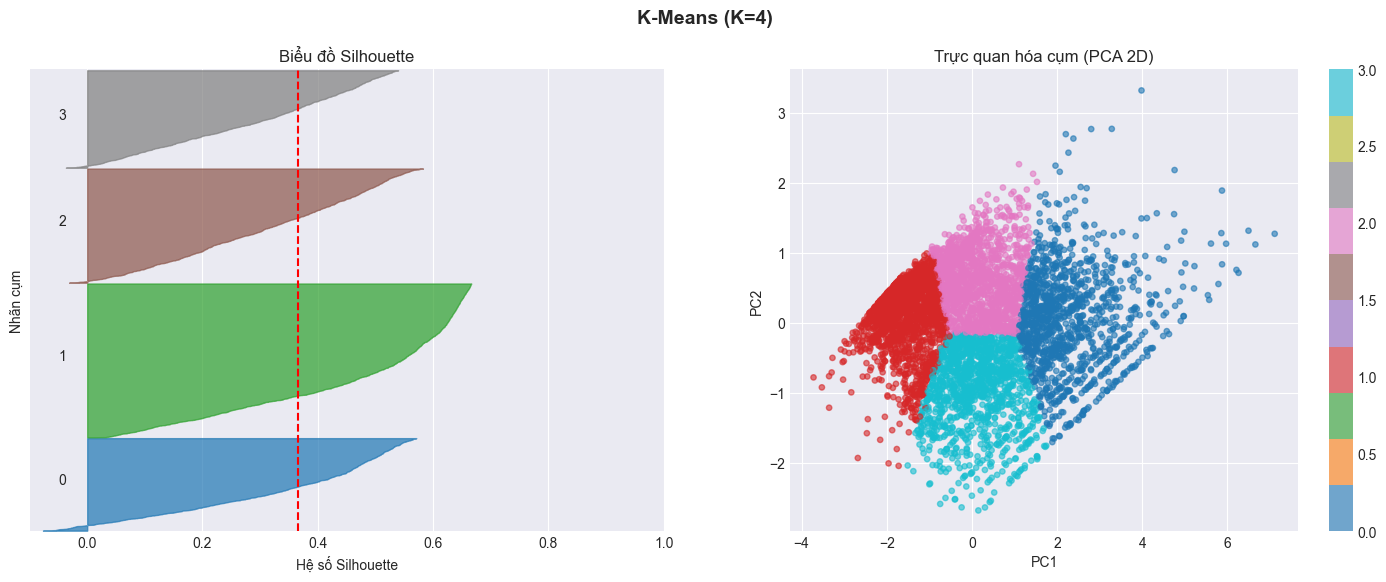

In [48]:
plot_silhouette(X, km_labels, f"K-Means (K={K_OPTIMAL})")

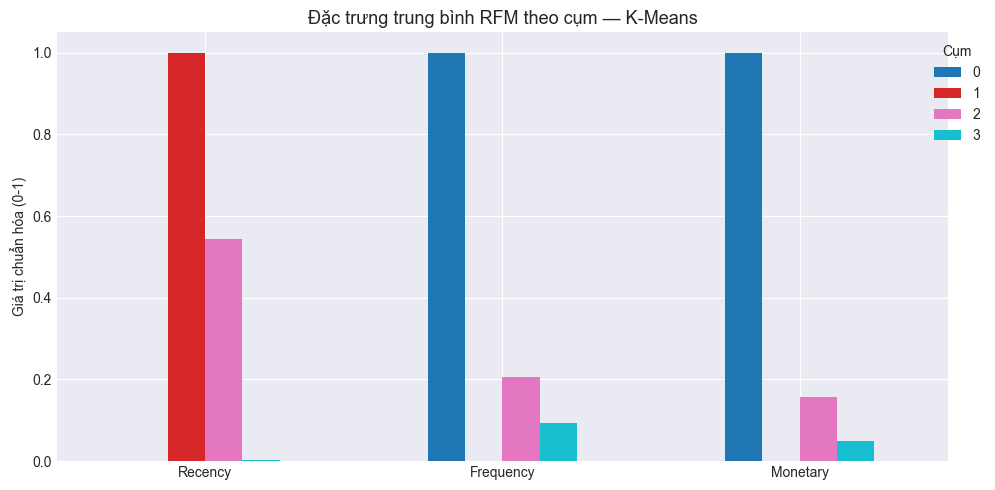


Giá trị RFM trung bình theo cụm:
         Recency  Frequency  Monetary
Cluster                              
0          27.43      19.34  11014.37
1         395.86       1.38    325.75
2         227.87       5.10   2002.10
3          28.44       3.04    865.11


In [49]:
km_means = plot_rfm_clusters(rfm, km_labels, "K-Means")
print("\nGiá trị RFM trung bình theo cụm:")
print(km_means.round(2))

# 8. Agglomerative Hierarchical Clustering

**Agglomerative Clustering** là phương pháp từ dưới lên (bottom-up): ban đầu mỗi điểm là một cụm, sau đó gộp dần hai cụm gần nhau nhất cho đến khi còn lại số cụm mong muốn.

**Dendrogram** giúp trực quan hóa quá trình gộp và chọn ngưỡng cắt (số cụm).

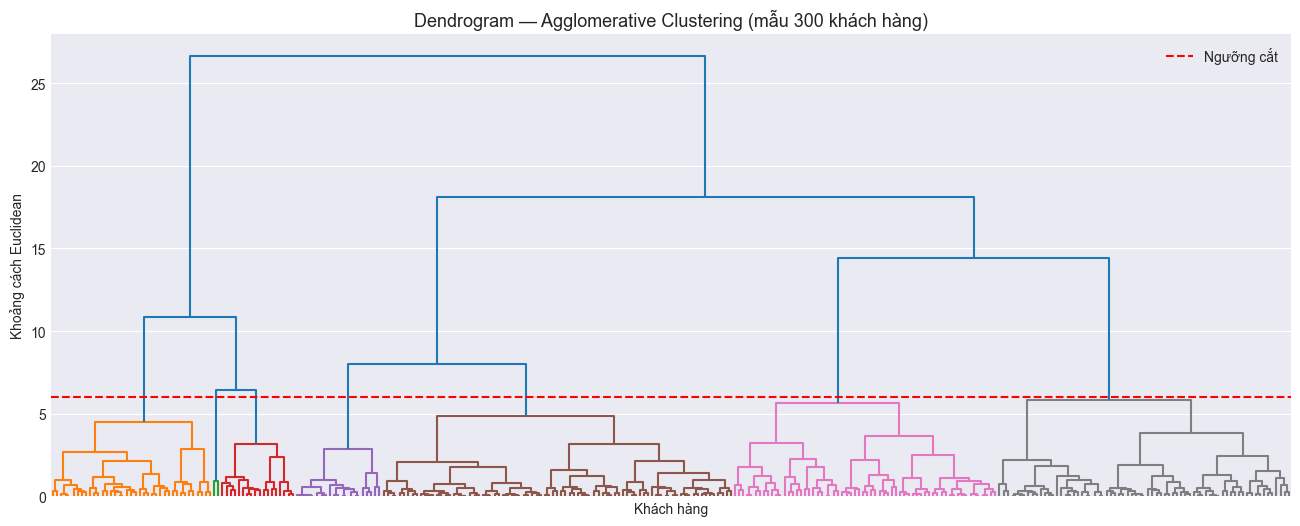

In [50]:
# Vẽ Dendrogram (dùng mẫu nhỏ để nhanh hơn)
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(300, len(X)), replace=False)
X_sample = X[sample_idx]

plt.figure(figsize=(16, 6))
dendrogram = shc.dendrogram(
    shc.linkage(X_sample, method="ward"),
    no_labels=True, color_threshold=6
)
plt.title("Dendrogram — Agglomerative Clustering (mẫu 300 khách hàng)", fontsize=13)
plt.xlabel("Khách hàng")
plt.ylabel("Khoảng cách Euclidean")
plt.axhline(y=6, color="red", linestyle="--", label="Ngưỡng cắt")
plt.legend()
plt.show()

In [51]:
AGG_CLUSTERS = 4  # Điều chỉnh dựa trên dendrogram

agg = AgglomerativeClustering(n_clusters=AGG_CLUSTERS, metric="euclidean", linkage="ward")
agg_labels = agg.fit_predict(X)
rfm["Agg_Cluster"] = agg_labels

print_scores(agg_labels, X, "Agglomerative")
print("\nSố khách hàng mỗi cụm:")
print(pd.Series(agg_labels).value_counts().sort_index())

[Agglomerative] Số cụm: 4 | Silhouette: 0.3031 | Davies-Bouldin: 0.9584

Số khách hàng mỗi cụm:
0    1831
1    1620
2    1472
3     955
Name: count, dtype: int64


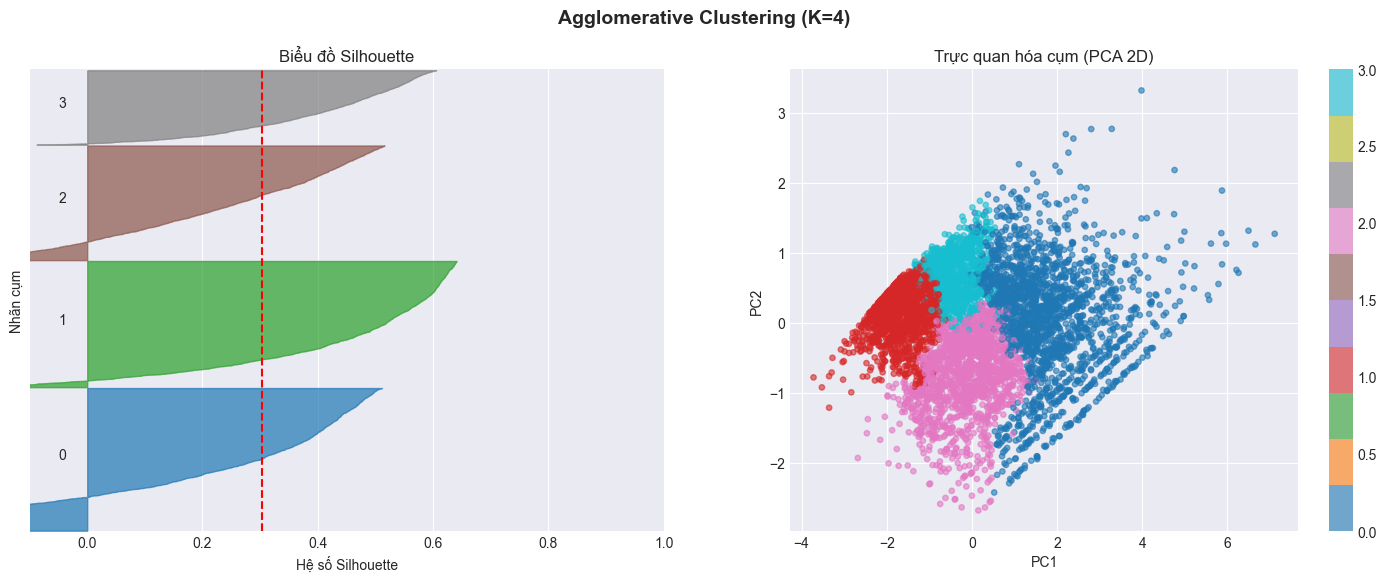

In [52]:
plot_silhouette(X, agg_labels, f"Agglomerative Clustering (K={AGG_CLUSTERS})")

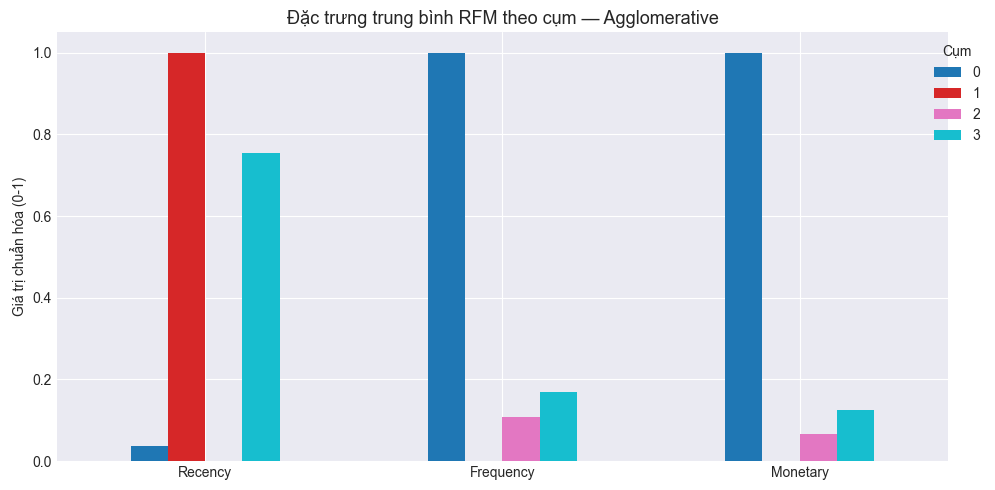


Giá trị RFM trung bình theo cụm:
         Recency  Frequency  Monetary
Cluster                              
0          57.17      14.86   8151.04
1         429.66       1.34    277.62
2          42.99       2.81    793.55
3         334.48       3.62   1257.61


In [53]:
agg_means = plot_rfm_clusters(rfm, agg_labels, "Agglomerative")
print("\nGiá trị RFM trung bình theo cụm:")
print(agg_means.round(2))

# 9. DBSCAN

**DBSCAN** là thuật toán phân cụm dựa trên mật độ. Thay vì cần chỉ định số cụm, DBSCAN tự tìm các vùng dày đặc và đánh dấu các điểm nằm ở vùng thưa là **nhiễu (-1)**.

**Hai tham số chính:**
- `eps`: bán kính vùng lân cận
- `min_samples`: số điểm tối thiểu trong vùng lân cận để tạo thành điểm lõi

**Tìm eps tốt:** Dùng k-distance graph — tìm điểm "khuỷu tay" trên đồ thị.

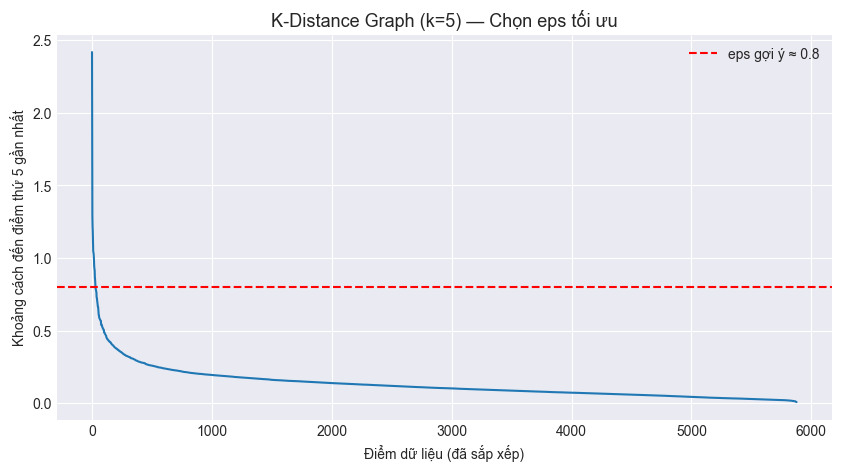

In [54]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, _ = nbrs.kneighbors(X)
distances = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("K-Distance Graph (k=5) — Chọn eps tối ưu", fontsize=13)
plt.xlabel("Điểm dữ liệu (đã sắp xếp)")
plt.ylabel("Khoảng cách đến điểm thứ 5 gần nhất")
plt.axhline(y=0.8, color="red", linestyle="--", label="eps gợi ý ≈ 0.8")
plt.legend()
plt.show()

 eps  n_clusters  noise
0.10          96   2487
0.15          57   1246
0.20          22    579
0.25          12    352
0.30           6    228
0.35           4    138
0.40           3    103
0.45           2     71
0.50           2     63
0.55           1     46
0.60           1     38
0.65           2     29
0.70           2     21
0.75           1     15
0.80           1     12
0.85           1     11
0.90           1     10
0.95           1     10


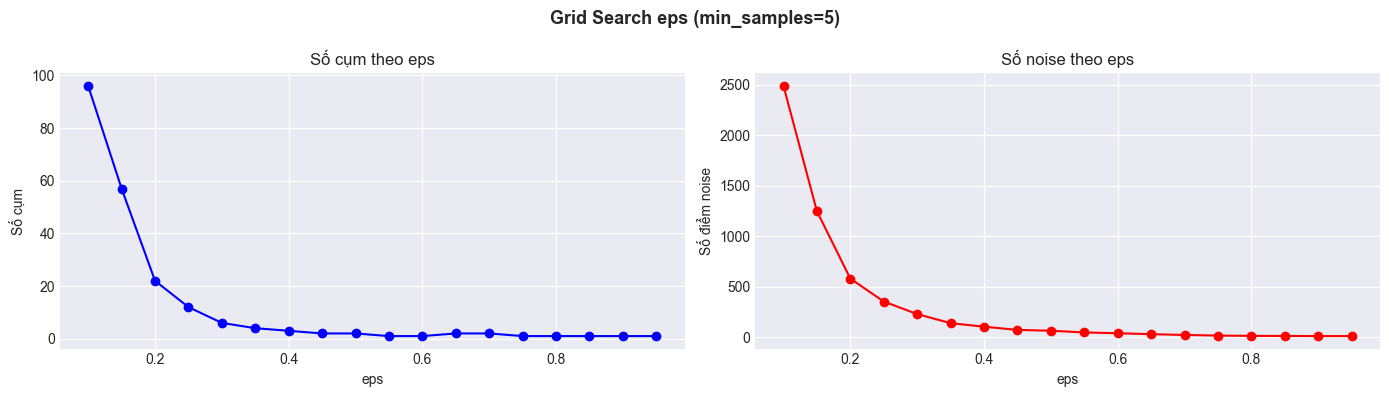


Eps được chọn: 0.7  →  2.0 cụm, noise=21.0

Số cụm tìm được: 2
Số điểm nhiễu: 21 (0.4%)
Phân bố nhãn: {-1: 21, 0: 5852, 1: 5}


In [55]:
# --- Grid search eps để xem số cụm thay đổi thế nào ---
from sklearn.neighbors import NearestNeighbors

eps_candidates = np.arange(0.1, 1.0, 0.05)
search_results = []
for e in eps_candidates:
    lbl = DBSCAN(eps=e, min_samples=5).fit_predict(X)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()
    search_results.append({"eps": round(e, 2), "n_clusters": n_c, "noise": n_noise})

sr = pd.DataFrame(search_results)
print(sr.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(sr["eps"], sr["n_clusters"], "bo-")
ax1.set_title("Số cụm theo eps"); ax1.set_xlabel("eps"); ax1.set_ylabel("Số cụm")
ax2.plot(sr["eps"], sr["noise"], "ro-")
ax2.set_title("Số noise theo eps"); ax2.set_xlabel("eps"); ax2.set_ylabel("Số điểm noise")
plt.suptitle("Grid Search eps (min_samples=5)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Chọn eps tốt nhất: nhiều hơn 1 cụm, noise không quá nhiều ---
good = sr[(sr["n_clusters"] >= 2) & (sr["noise"] / len(X) < 0.20)]
if len(good) > 0:
    best_eps = good.iloc[-1]["eps"]   # eps lớn nhất vẫn cho ≥2 cụm & noise <20%
    print(f"\nEps được chọn: {best_eps}  →  {good.iloc[-1]['n_clusters']} cụm, noise={good.iloc[-1]['noise']}")
else:
    best_eps = 0.5
    print(f"\nKhông tìm được eps tốt, dùng mặc định eps={best_eps}")

EPS = best_eps
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X)
rfm["DBSCAN_Cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"\nSố cụm tìm được: {n_clusters}")
print(f"Số điểm nhiễu: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print("Phân bố nhãn:", pd.Series(db_labels).value_counts().sort_index().to_dict())

[DBSCAN] Số cụm: 2 | Silhouette: 0.5140 | Davies-Bouldin: 1.0387


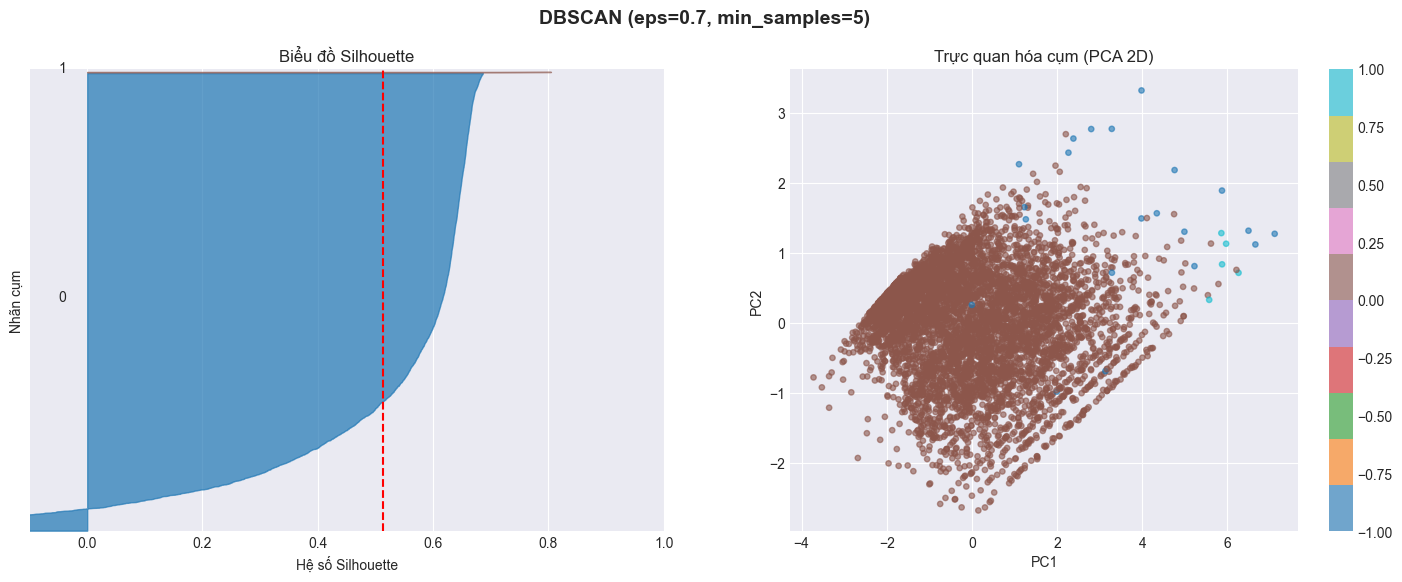

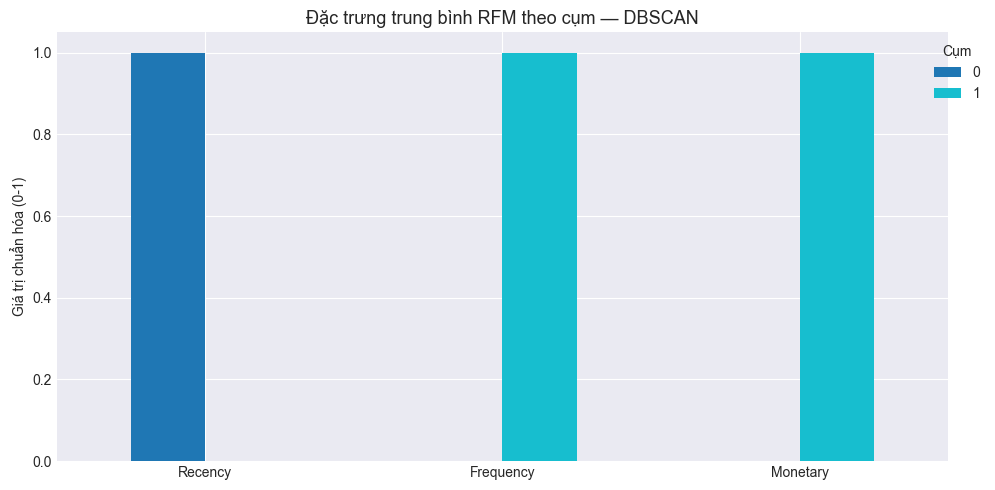

In [56]:
if len(set(db_labels)) - (1 if -1 in db_labels else 0) >= 2:
    print_scores(db_labels, X, "DBSCAN")
    plot_silhouette(X, db_labels, f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})")
    plot_rfm_clusters(rfm, db_labels, "DBSCAN")
else:
    print("DBSCAN tìm được < 2 cụm. Hãy thử điều chỉnh eps và min_samples.")

# 10. So Sánh Các Thuật Toán

Tổng hợp chỉ số đánh giá để so sánh ba thuật toán.

In [57]:
results = []
for name, labels in [("K-Means", km_labels), ("Agglomerative", agg_labels), ("DBSCAN", db_labels)]:
    valid = labels[labels != -1]
    X_valid = X[labels != -1]
    n_c = len(set(valid))
    if n_c >= 2:
        sil = silhouette_score(X_valid, valid)
        db  = davies_bouldin_score(X_valid, valid)
        noise = (labels == -1).sum()
    else:
        sil, db, noise = None, None, (labels == -1).sum()
    results.append({"Thuật toán": name, "Số cụm": n_c, "Silhouette ↑": sil, "Davies-Bouldin ↓": db, "Nhiễu": noise})

summary = pd.DataFrame(results).set_index("Thuật toán")
print(summary.to_string())

               Số cụm  Silhouette ↑  Davies-Bouldin ↓  Nhiễu
Thuật toán                                                  
K-Means             4          0.37              0.93      0
Agglomerative       4          0.30              0.96      0
DBSCAN              2          0.62              0.34     21


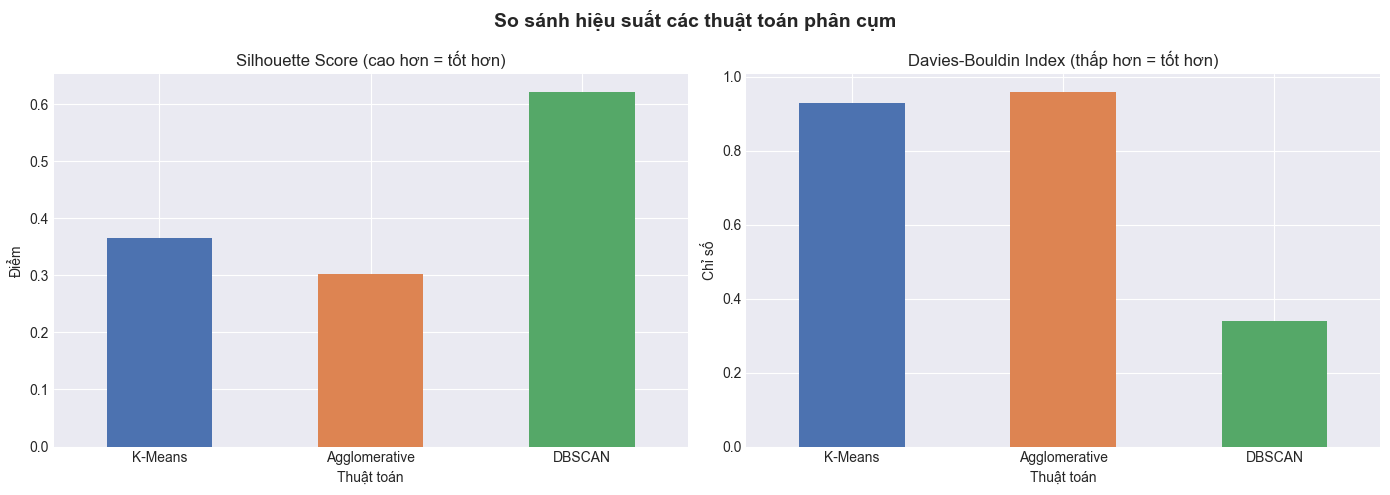

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_results = summary.dropna()
valid_results["Silhouette ↑"].plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452","#55A868"], rot=0)
axes[0].set_title("Silhouette Score (cao hơn = tốt hơn)")
axes[0].set_ylabel("Điểm")

valid_results["Davies-Bouldin ↓"].plot(kind="bar", ax=axes[1], color=["#4C72B0","#DD8452","#55A868"], rot=0)
axes[1].set_title("Davies-Bouldin Index (thấp hơn = tốt hơn)")
axes[1].set_ylabel("Chỉ số")

plt.suptitle("So sánh hiệu suất các thuật toán phân cụm", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 11. Phân Tích Phân Khúc Khách Hàng (K-Means)

Dùng kết quả K-Means (thường tốt nhất) để đặt tên và mô tả từng phân khúc.

In [59]:
seg = rfm.groupby("KMeans_Cluster")[["Recency","Frequency","Monetary"]].mean().round(1)
seg["Số KH"] = rfm.groupby("KMeans_Cluster").size()
seg["% KH"]  = (seg["Số KH"] / len(rfm) * 100).round(1)

# Gắn nhãn phân khúc dựa trên giá trị RFM
# Recency thấp + Frequency cao + Monetary cao → Khách VIP
print("Thống kê RFM theo cụm K-Means:")
print(seg.to_string())

# Gợi ý đặt tên (người dùng có thể thay đổi dựa trên giá trị thực tế)
print("\n💡 Gợi ý phân khúc:")
print("  Cụm có Recency thấp + Frequency cao + Monetary cao  → Khách VIP / Trung thành")
print("  Cụm có Recency thấp + Frequency thấp + Monetary thấp → Khách mới")
print("  Cụm có Recency cao  + Frequency thấp                 → Khách không hoạt động")
print("  Cụm có Recency trung bình + Monetary cao             → Khách tiềm năng")

Thống kê RFM theo cụm K-Means:
                Recency  Frequency  Monetary  Số KH  % KH
KMeans_Cluster                                           
0                 27.40      19.30  11014.40   1188 20.20
1                395.90       1.40    325.70   1974 33.60
2                227.90       5.10   2002.10   1465 24.90
3                 28.40       3.00    865.10   1251 21.30

💡 Gợi ý phân khúc:
  Cụm có Recency thấp + Frequency cao + Monetary cao  → Khách VIP / Trung thành
  Cụm có Recency thấp + Frequency thấp + Monetary thấp → Khách mới
  Cụm có Recency cao  + Frequency thấp                 → Khách không hoạt động
  Cụm có Recency trung bình + Monetary cao             → Khách tiềm năng


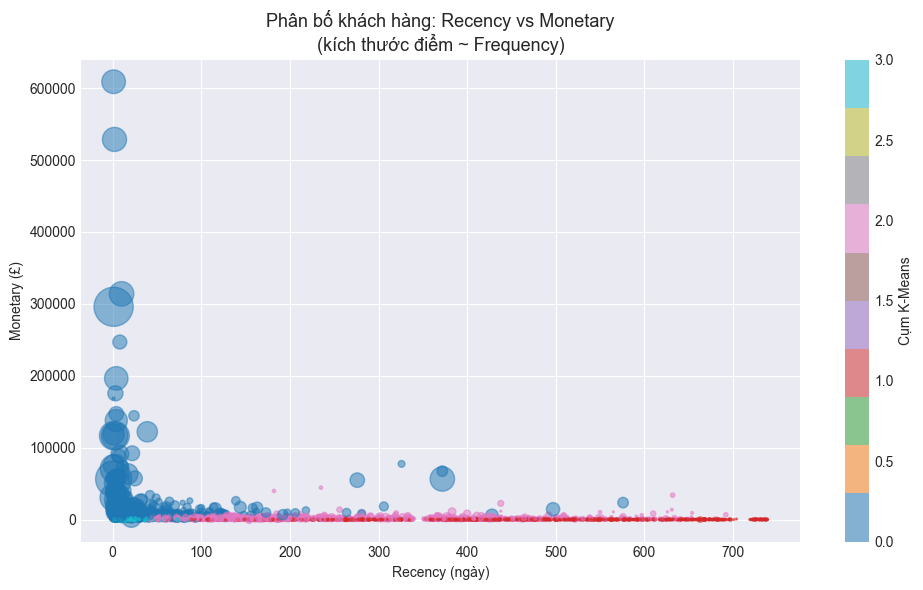

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    rfm["Recency"], rfm["Monetary"],
    c=rfm["KMeans_Cluster"], cmap="tab10",
    s=rfm["Frequency"]*2, alpha=0.5
)
plt.colorbar(scatter, label="Cụm K-Means")
ax.set_xlabel("Recency (ngày)")
ax.set_ylabel("Monetary (£)")
ax.set_title("Phân bố khách hàng: Recency vs Monetary\n(kích thước điểm ~ Frequency)", fontsize=13)
plt.tight_layout()
plt.show()

# 12. Kết Luận

>Thực nghiệm phân khúc khách hàng trên tập dữ liệu **Online Retail II** với ba thuật toán:

| Thuật toán | Ưu điểm | Nhược điểm |
|------------|---------|------------|
| **K-Means** | Nhanh, cho cụm đều, dễ giải thích | Cần biết trước K, nhạy với ngoại lệ |
| **Agglomerative** | Không cần K trước, dendrogram trực quan | Chậm với dữ liệu lớn |
| **DBSCAN** | Tự tìm K, xử lý nhiễu tốt | Khó chọn eps, kém với mật độ không đều |

>**Nhận xét:** Trên dữ liệu RFM, K-Means thường cho kết quả tốt và dễ giải thích nhất nhờ các cụm có ý nghĩa kinh doanh rõ ràng. DBSCAN hữu ích để phát hiện khách hàng bất thường (ngoại lệ).

# 13. Biểu đồ 3D Kết quả Phân Cụm (xoay được)

Trực quan hóa 3 chiều trên không gian **Recency × Frequency × Monetary** — kéo chuột để xoay, scroll để zoom.

In [61]:
import plotly.graph_objects as go

R = rfm["Recency"].values
F = rfm["Frequency"].values
M = rfm["Monetary"].values

PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
]

def plot_3d_rfm(labels, title):
    fig = go.Figure()
    for label in np.unique(labels):
        mask = labels == label
        if label == -1:
            color, name, symbol, size = 'lightgray', 'Noise', 'x', 3
        else:
            color, name, symbol, size = PALETTE[label % len(PALETTE)], f'Cụm {label}', 'circle', 5
        fig.add_trace(go.Scatter3d(
            x=R[mask], y=F[mask], z=M[mask],
            mode='markers', name=name,
            marker=dict(color=color, size=size, symbol=symbol,
                        line=dict(color='darkgray', width=0.5), opacity=0.8),
            hovertemplate=(
                f'<b>{name}</b><br>'
                'Recency: %{x} ngày<br>'
                'Frequency: %{y}<br>'
                'Monetary: £%{z:,.0f}<extra></extra>'
            ),
        ))
    fig.update_layout(
        title_text=title, title_x=0.5, height=580,
        scene=dict(
            xaxis_title='Recency (ngày)',
            yaxis_title='Frequency (hóa đơn)',
            zaxis_title='Monetary (£)',
        ),
        legend=dict(title='Cụm', itemsizing='constant'),
        margin=dict(l=0, r=0, t=50, b=0),
    )
    fig.show()

In [62]:
plot_3d_rfm(km_labels, f'K-Means (k={K_OPTIMAL}) — Recency × Frequency × Monetary')

In [63]:
plot_3d_rfm(agg_labels, f'Agglomerative (Ward, k={AGG_CLUSTERS}) — Recency × Frequency × Monetary')

In [64]:
plot_3d_rfm(db_labels, f'DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — Recency × Frequency × Monetary')